In [4]:
# pip install xgboost shap

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 1.1 MB/s eta 0:01:31
   ---------------------------------------- 1.0/101.7 MB 1.3 MB/s eta 0:01:18
    --------------------------------------- 1.3/101.7 MB 1.2 MB/s eta 0:01:26
    --------------------------------------- 1.6/101.7 MB 1.3 MB/s eta 0:01:17
    --------------------------------------- 1.8/101.7 MB 1.2 MB/s eta 0:01:22
    --------------------------------------- 2.1/101.7 MB 1.3 MB/s eta 0:01:16
    --------------------------------------- 2.4/101.7 MB 1.2 MB/s eta 0:01:26
   - -------------------------------------- 2.6/101.7 MB 1.3 MB/s eta 0:01:18
   - -------------------------------------- 2.9/101.7 MB 1.3 MB/s eta 0:01:19
   - ---------

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, f1_score,
    precision_score, recall_score
)

pd.set_option('display.float_format', '{:.4f}'.format)

# Load clean engineered dataset
df = pd.read_csv(r"C:\Users\HP\Documents\ML Project\data\processed\application_train_clean.csv")

# Separate features and target
X = df.drop(columns=['TARGET'])
y = df['TARGET']

# Same split as baseline — random_state=42 guarantees identical split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Shape: {df.shape}")
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Default rate — Train: {y_train.mean()*100:.2f}% | Test: {y_test.mean()*100:.2f}%")

Shape: (307511, 102)
Train: 246,008 | Test: 61,503
Default rate — Train: 8.07% | Test: 8.07%


## Day 4: XGBoost + SHAP Explainability

### What changes from the baseline:
- Algorithm: Logistic Regression → XGBoost
- Data: identical — same split, same features, same preprocessing
- No StandardScaler needed — tree-based models are scale-invariant
- Imbalance handling: scale_pos_weight instead of class_weight='balanced'

### Why no scaling for XGBoost?
Logistic Regression uses a weighted sum of features — large magnitude 
features dominate if unscaled. XGBoost uses decision trees that split 
on feature thresholds — the scale of a feature is irrelevant to where 
the best split point is. A split at income > 150,000 works identically 
whether income is in raw naira or scaled units.

### scale_pos_weight calculation:
The ratio of negative to positive class = non-defaults / defaults
This tells XGBoost to weight each default case as if it appeared 
that many times more in the training data.

In [12]:
# Count negatives and positives in training set
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f"Non-defaults (0): {neg_count:,}")
print(f"Defaults (1):     {pos_count:,}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")
print(f"\nInterpretation: XGBoost will treat each default case")
print(f"as if it appeared {scale_pos_weight:.1f}x in the training data")

Non-defaults (0): 226,148
Defaults (1):     19,860
scale_pos_weight: 11.39

Interpretation: XGBoost will treat each default case
as if it appeared 11.4x in the training data


In [14]:
xgb_model = xgb.XGBClassifier(
    n_estimators=500,           # number of trees
    max_depth=6,                # how deep each tree grows
    learning_rate=0.05,         # how much each tree corrects the previous
    subsample=0.8,              # 80% of rows sampled per tree — reduces overfitting
    colsample_bytree=0.8,       # 80% of features sampled per tree
    scale_pos_weight=scale_pos_weight,  # handles class imbalance
    random_state=42,
    eval_metric='auc',          # monitor AUC during training
    early_stopping_rounds=50,   # stop if no improvement after 50 rounds
    verbosity=1
)

print("Training XGBoost...")
print("(500 trees with early stopping — may take 2-3 minutes)")

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100                 # print progress every 100 trees
)

print(f"\nBest iteration: {xgb_model.best_iteration}")
print("Training complete.")

Training XGBoost...
(500 trees with early stopping — may take 2-3 minutes)
[0]	validation_0-auc:0.72429
[100]	validation_0-auc:0.76151
[200]	validation_0-auc:0.76666
[300]	validation_0-auc:0.76770
[326]	validation_0-auc:0.76738

Best iteration: 276
Training complete.


In [16]:
# Predictions
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_class_xgb = xgb_model.predict(X_test)

# Core metrics
auc_roc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
avg_precision_xgb = average_precision_score(y_test, y_pred_proba_xgb)
f1_xgb = f1_score(y_test, y_pred_class_xgb)
precision_xgb = precision_score(y_test, y_pred_class_xgb)
recall_xgb = recall_score(y_test, y_pred_class_xgb)

# Baseline scores for comparison
auc_roc_lr = 0.7484
f1_lr = 0.2598

print("=" * 55)
print("MODEL COMPARISON: LR BASELINE vs XGBOOST")
print("=" * 55)
print(f"{'Metric':<25} {'Log Reg':>10} {'XGBoost':>10} {'Improvement':>12}")
print("-" * 55)
print(f"{'AUC-ROC':<25} {auc_roc_lr:>10.4f} {auc_roc_xgb:>10.4f} {(auc_roc_xgb-auc_roc_lr)*100:>+11.2f}%")
print(f"{'Avg Precision':<25} {'—':>10} {avg_precision_xgb:>10.4f}")
print(f"{'F1 Score':<25} {'—':>10} {f1_xgb:>10.4f}")
print(f"{'Precision':<25} {'—':>10} {precision_xgb:>10.4f}")
print(f"{'Recall':<25} {'—':>10} {recall_xgb:>10.4f}")
print("=" * 55)

MODEL COMPARISON: LR BASELINE vs XGBOOST
Metric                       Log Reg    XGBoost  Improvement
-------------------------------------------------------
AUC-ROC                       0.7484     0.7679       +1.95%
Avg Precision                      —     0.2557
F1 Score                           —     0.2836
Precision                          —     0.1808
Recall                             —     0.6580


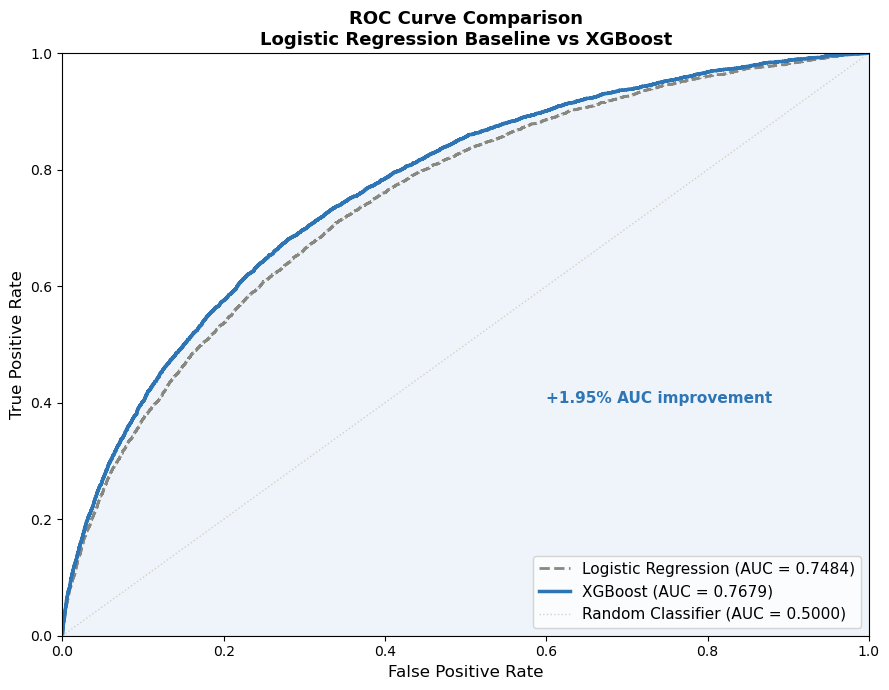

AUC improvement: +1.9466 (1.95%)


In [18]:
# Load baseline predictions for comparison
# Re-run baseline quickly to get its curve
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    C=0.1
)
lr_model.fit(X_train_scaled, y_train)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Plot both ROC curves together
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)

auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(fpr_lr, tpr_lr, color='#888780', linewidth=2, linestyle='--',
        label=f'Logistic Regression (AUC = {auc_lr:.4f})')
ax.plot(fpr_xgb, tpr_xgb, color='#2E75B6', linewidth=2.5,
        label=f'XGBoost (AUC = {auc_xgb:.4f})')
ax.plot([0, 1], [0, 1], color='#D3D1C7', linestyle=':', 
        linewidth=1, label='Random Classifier (AUC = 0.5000)')
ax.fill_between(fpr_xgb, tpr_xgb, alpha=0.08, color='#2E75B6')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison\nLogistic Regression Baseline vs XGBoost',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Annotate the improvement
improvement = (auc_xgb - auc_lr) * 100
ax.annotate(f'+{improvement:.2f}% AUC improvement',
            xy=(0.6, 0.4), fontsize=11,
            color='#2E75B6', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"AUC improvement: +{improvement:.4f} ({improvement:.2f}%)")

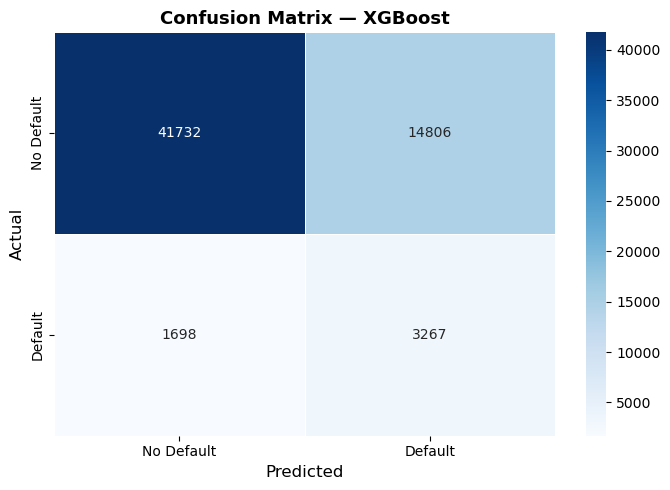


XGBoost Confusion Matrix:
Bad loans caught:   3,267 / 4,965 (65.8%)
Bad loans missed:   1,698 / 4,965 (34.2%)
Good loans rejected: 14,806


In [20]:
fig, ax = plt.subplots(figsize=(7, 5))

cm_xgb = confusion_matrix(y_test, y_pred_class_xgb)
cm_labels = ['No Default', 'Default']

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=cm_labels, yticklabels=cm_labels,
            ax=ax, linewidths=0.5)

ax.set_ylabel('Actual', fontsize=12)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_title('Confusion Matrix — XGBoost', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/confusion_matrix_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm_xgb.ravel()
total_defaults = fn + tp
print(f"\nXGBoost Confusion Matrix:")
print(f"Bad loans caught:   {tp:,} / {total_defaults:,} ({tp/total_defaults*100:.1f}%)")
print(f"Bad loans missed:   {fn:,} / {total_defaults:,} ({fn/total_defaults*100:.1f}%)")
print(f"Good loans rejected: {fp:,}")

In [21]:
print("Calculating SHAP values — this takes 3-5 minutes...")
print("Do not interrupt the kernel.")

# TreeExplainer is optimised for tree-based models
# Much faster than the generic KernelExplainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for test set
# Use a sample of 5000 for speed — still statistically representative
sample_idx = np.random.choice(len(X_test), size=5000, replace=False)
X_test_sample = X_test.iloc[sample_idx]
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values calculated.")
print(f"Shape: {shap_values.shape}")

Calculating SHAP values — this takes 3-5 minutes...
Do not interrupt the kernel.
SHAP values calculated.
Shape: (5000, 101)


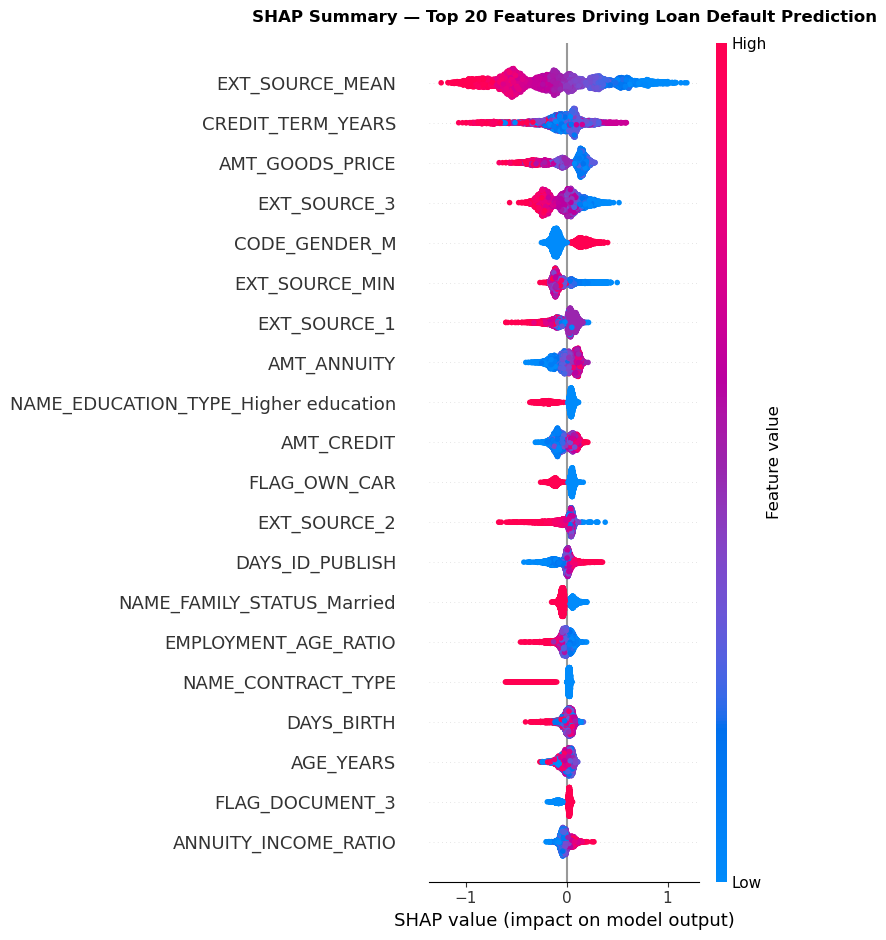

SHAP summary saved.


In [24]:
plt.figure(figsize=(10, 10))

shap.summary_plot(
    shap_values,
    X_test_sample,
    max_display=20,     # show top 20 features
    show=False
)

plt.title('SHAP Summary — Top 20 Features Driving Loan Default Prediction',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP summary saved.")

Analysing high-risk borrower at index: 4299
Predicted default probability: 94.1%
Actual outcome: Did not default


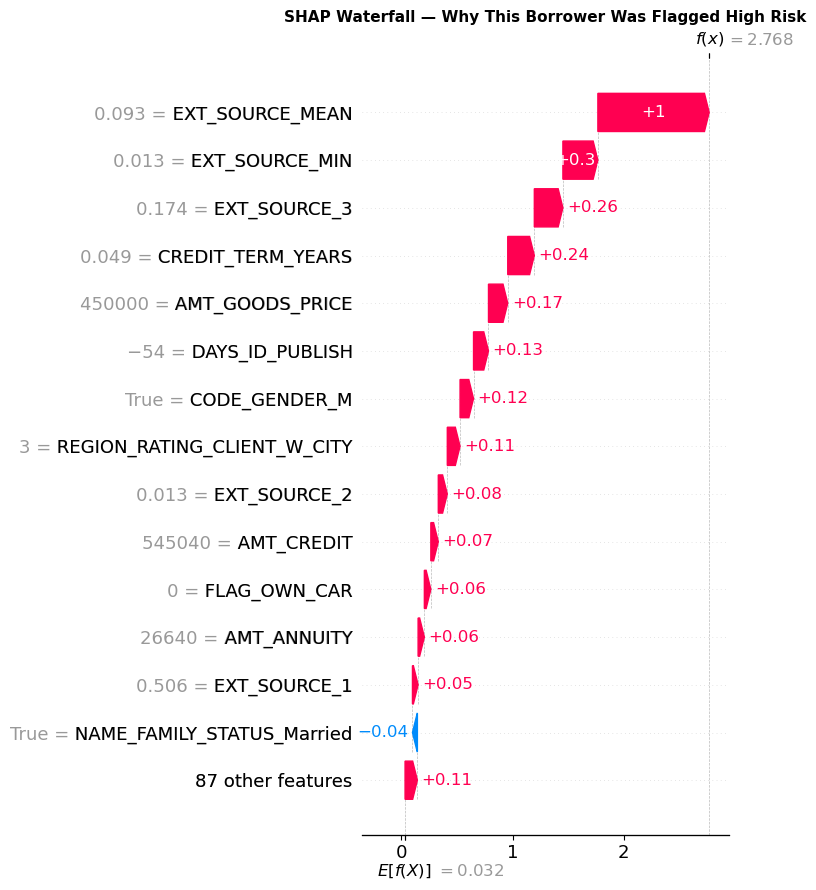

In [26]:
# Find a high-risk borrower in the test sample — someone the model
# flagged with high default probability
high_risk_idx = np.argmax(
    xgb_model.predict_proba(X_test_sample)[:, 1]
)

print(f"Analysing high-risk borrower at index: {high_risk_idx}")
print(f"Predicted default probability: "
      f"{xgb_model.predict_proba(X_test_sample)[high_risk_idx, 1]*100:.1f}%")
print(f"Actual outcome: "
      f"{'Defaulted' if y_test.iloc[sample_idx[high_risk_idx]]==1 else 'Did not default'}")

# Waterfall plot — explains this single prediction
plt.figure(figsize=(10, 8))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_test_sample.iloc[high_risk_idx],
        feature_names=X_test.columns.tolist()
    ),
    show=False,
    max_display=15
)
plt.title('SHAP Waterfall — Why This Borrower Was Flagged High Risk',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 900x600 with 0 Axes>

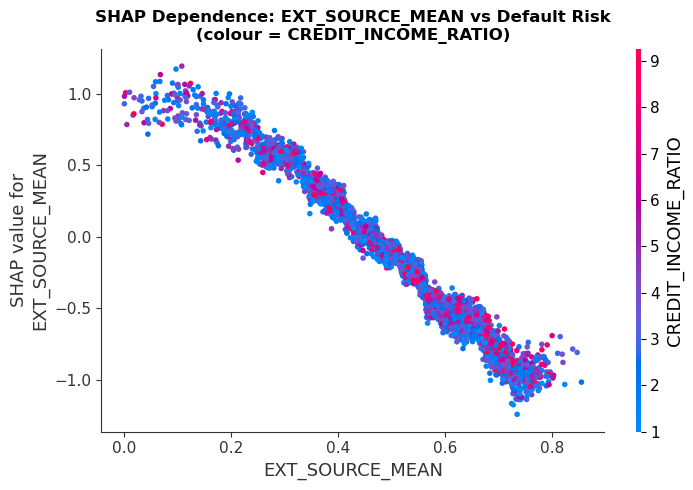

In [28]:
# Dependence plot for EXT_SOURCE_MEAN
# Shows how its effect on default risk changes with its value
# and how it interacts with CREDIT_INCOME_RATIO

plt.figure(figsize=(9, 6))
shap.dependence_plot(
    'EXT_SOURCE_MEAN',
    shap_values,
    X_test_sample,
    interaction_index='CREDIT_INCOME_RATIO',
    show=False
)
plt.title('SHAP Dependence: EXT_SOURCE_MEAN vs Default Risk\n'
          '(colour = CREDIT_INCOME_RATIO)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
print("=" * 55)
print(f"\n--- Model Comparison ---")
print(f"Logistic Regression AUC-ROC:  {auc_lr:.4f}  (baseline)")
print(f"XGBoost AUC-ROC:              {auc_xgb:.4f}  (champion)")
print(f"Improvement:                  +{(auc_xgb-auc_lr)*100:.2f}%")
print(f"\n--- SHAP Explainability ---")
print(f"Global summary:    reports/shap_summary.png")
print(f"Single prediction: reports/shap_waterfall.png")
print(f"Feature interaction: reports/shap_dependence.png")
print(f"\n--- Charts saved ---")
print(f"reports/roc_comparison.png")
print(f"reports/confusion_matrix_xgb.png")
print("=" * 55)


--- Model Comparison ---
Logistic Regression AUC-ROC:  0.7484  (baseline)
XGBoost AUC-ROC:              0.7679  (champion)
Improvement:                  +1.95%

--- SHAP Explainability ---
Global summary:    reports/shap_summary.png
Single prediction: reports/shap_waterfall.png
Feature interaction: reports/shap_dependence.png

--- Charts saved ---
reports/roc_comparison.png
reports/confusion_matrix_xgb.png


In [32]:
import joblib
import os

os.makedirs(r"C:\Users\HP\Documents\ML Project\loan-default-prediction-\models", exist_ok=True)

# Save XGBoost model
joblib.dump(xgb_model, r'C:\Users\HP\Documents\ML Project\loan-default-prediction-/models/xgb_model.pkl')

# Save feature names
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, r'C:\Users\HP\Documents\ML Project\loan-default-prediction-/models/feature_names.pkl')

# Save training data stats for reference
joblib.dump(X_train.describe(), r'C:\Users\HP\Documents\ML Project\loan-default-prediction-/models/train_stats.pkl')

print("Saved successfully.")
print(f"Total features: {len(feature_names)}")

Saved successfully.
Total features: 101


In [34]:
# ─────────────────────────────────────────
# RETRAIN WITHOUT GENDER
# Dalex analysis flagged CODE_GENDER_M as 4th most important
# feature. Using gender in credit scoring creates regulatory
# and ethical exposure in CBN-regulated institutions.
# We remove it, retrain, and measure the performance impact.
# ─────────────────────────────────────────

from sklearn.metrics import roc_auc_score, recall_score, f1_score

# Remove gender from features
gender_col = 'CODE_GENDER_M'
X_train_ng = X_train.drop(columns=[gender_col])
X_test_ng = X_test.drop(columns=[gender_col])

print(f"Features before: {X_train.shape[1]}")
print(f"Features after removing gender: {X_train_ng.shape[1]}")
print(f"Column removed: {gender_col}")

# Recalculate scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos

# Retrain XGBoost without gender
xgb_no_gender = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=50,
    verbosity=0
)

print("\nRetraining without gender variable...")
xgb_no_gender.fit(
    X_train_ng, y_train,
    eval_set=[(X_test_ng, y_test)],
    verbose=False
)
print("Done.")

# Evaluate
y_prob_ng = xgb_no_gender.predict_proba(X_test_ng)[:, 1]
y_pred_ng = xgb_no_gender.predict(X_test_ng)

auc_ng = roc_auc_score(y_test, y_prob_ng)
recall_ng = recall_score(y_test, y_pred_ng)
f1_ng = f1_score(y_test, y_pred_ng)

print("\n" + "=" * 55)
print("MODEL COMPARISON: With vs Without Gender")
print("=" * 55)
print(f"{'Metric':<20} {'With Gender':>15} {'Without Gender':>15}")
print("-" * 55)
print(f"{'AUC-ROC':<20} {0.7679:>15.4f} {auc_ng:>15.4f}")
print(f"{'Recall':<20} {0.6580:>15.4f} {recall_ng:>15.4f}")
print(f"{'F1 Score':<20} {0.2836:>15.4f} {f1_ng:>15.4f}")
print("=" * 55)

if auc_ng >= 0.76:
    print("\n✅ Performance maintained without gender.")
    print("   Safe to deploy gender-free model.")
elif auc_ng >= 0.74:
    print("\n⚡ Minor performance drop — acceptable tradeoff")
    print("   for regulatory compliance.")
else:
    print("\n⚠️  Significant drop — investigate further.")

Features before: 101
Features after removing gender: 100
Column removed: CODE_GENDER_M

Retraining without gender variable...
Done.

MODEL COMPARISON: With vs Without Gender
Metric                   With Gender  Without Gender
-------------------------------------------------------
AUC-ROC                       0.7679          0.7664
Recall                        0.6580          0.6526
F1 Score                      0.2836          0.2813

✅ Performance maintained without gender.
   Safe to deploy gender-free model.


In [38]:
import joblib
import os

# Save the gender-free model
joblib.dump(
    xgb_no_gender,
    r'C:\Users\HP\Documents\ML Project\loan-default-prediction-/models/xgb_model_no_gender.pkl'
)

# Save updated feature names without gender
feature_names_ng = X_train_ng.columns.tolist()
joblib.dump(
    feature_names_ng,
    r'C:\Users\HP\Documents\ML Project\loan-default-prediction-/models/feature_names_no_gender.pkl'
)

print("Gender-free model saved.")
print(f"Features: {len(feature_names_ng)}")
print("\nFiles saved:")
print("  models/xgb_model_no_gender.pkl")
print("  models/feature_names_no_gender.pkl")

Gender-free model saved.
Features: 100

Files saved:
  models/xgb_model_no_gender.pkl
  models/feature_names_no_gender.pkl
